# Descarga de archivos parquet

In [1]:
# Instalacion de gdwon.
! pip install -q gdown

# Importacion de librerias.
import os
import gdown

# Enlace de la carpeta a descargar.
folder_link = 'https://drive.google.com/drive/folders/1c6mF0dFzz-UKhoCIF2EUZQJEwxyiI3q3?usp=drive_link'

# Directorio donde se guardarán los archivos
output_directory = './dw_parquet'
if not os.path.exists(output_directory):
  os.makedirs(output_directory, exist_ok=True)

# Descarga de carpeta y contenido.
try:
  print(f"Descargando archivos a: {output_directory}/")
  gdown.download_folder(url=folder_link, output=output_directory)
  print("Proceso de descarga completado.")
except Exception as e:
  print(f"Error al descargar la carpeta: {e}")

Descargando archivos a: ./dw_parquet/


Retrieving folder contents


Processing file 1bTCIq14P2Okl_oM1-WEbRN40tV6RQFoW rep_application_train.parquet
Processing file 1khhMtE4208o3xI_OVtcIsYc4_oDT2kN2 rep_bureau_balance.parquet
Processing file 1o-NHsZhJtnCDnoZuLHB0bWhZi7_vrKVF rep_bureau.parquet
Processing file 18g3xCAA3nTt3iXiE7-aefEY-N9f01rnX rep_credit_card_balance.parquet
Processing file 1e6QOWfweQgQOVsJs550JNt1c5mDpeMvf rep_installments_payments.parquet
Processing file 1GpV7ogCyPEptYpYPHgdQf3M8OTyZQG5j rep_pos_cash_balance.parquet
Processing file 1HS37I2dSfLCC6jYeZVJc9-x1L5I1GzRN rep_previous_application.parquet


Retrieving folder contents completed
Building directory structure
Building directory structure completed
Downloading...
From: https://drive.google.com/uc?id=1bTCIq14P2Okl_oM1-WEbRN40tV6RQFoW
To: /content/dw_parquet/rep_application_train.parquet
100%|██████████| 18.6M/18.6M [00:01<00:00, 10.2MB/s]
Downloading...
From: https://drive.google.com/uc?id=1khhMtE4208o3xI_OVtcIsYc4_oDT2kN2
To: /content/dw_parquet/rep_bureau_balance.parquet
100%|██████████| 97.9M/97.9M [00:01<00:00, 69.8MB/s]
Downloading...
From: https://drive.google.com/uc?id=1o-NHsZhJtnCDnoZuLHB0bWhZi7_vrKVF
To: /content/dw_parquet/rep_bureau.parquet
100%|██████████| 34.3M/34.3M [00:01<00:00, 31.3MB/s]
Downloading...
From (original): https://drive.google.com/uc?id=18g3xCAA3nTt3iXiE7-aefEY-N9f01rnX
From (redirected): https://drive.google.com/uc?id=18g3xCAA3nTt3iXiE7-aefEY-N9f01rnX&confirm=t&uuid=d1884786-1253-458e-91e2-a7858cf2c26e
To: /content/dw_parquet/rep_credit_card_balance.parquet
100%|██████████| 117M/117M [00:02<00:00, 

Proceso de descarga completado.



Download completed


# Análisis preliminar inicial

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# Constantes de configuración
DATA_DIR = Path('./dw_parquet')
TARGET_COL = 'TARGET'

class ParquetEDA:
    def __init__(self, file_path: Path):
        self.file_path = file_path
        self.df = None
        self.name = file_path.stem

    def load_data(self):
        """Carga el archivo parquet."""
        self.df = pd.read_parquet(self.file_path)
        print(f"--- Análisis de: {self.name} ---")

    def basic_info(self):
        """Muestra tamaño, shape, tipos y nulos."""
        stats = pd.DataFrame({
            'Tipo': self.df.dtypes,
            'Nulos': self.df.isnull().sum(),
            '% Nulos': (self.df.isnull().sum() / len(self.df)) * 100,
            'Unicos': self.df.nunique()
        })
        print(f"Shape: {self.df.shape}")
        print(f"Memoria: {self.df.memory_usage(deep=True).sum() / 1024**2:.2f} MB")
        display(stats)

    def correlation_analysis(self, target=None):
        """Analiza correlaciones numéricas."""
        num_df = self.df.select_dtypes(include=[np.number])
        if num_df.empty: return

        corr_matrix = num_df.corr()

        if target and target in self.df.columns:
            print(f"\nCorrelación top con {target}:")
            target_corr = corr_matrix[target].sort_values(ascending=False)
            display(target_corr.head(10))

        plt.figure(figsize=(10, 6))
        sns.heatmap(corr_matrix, cmap='coolwarm', annot=False)
        plt.title(f"Matriz de Correlación - {self.name}")
        plt.show()

    def variance_analysis(self):
        """Calcula la varianza de columnas numéricas para detectar baja variabilidad."""
        num_df = self.df.select_dtypes(include=[np.number])
        if num_df.empty: return

        variances = num_df.var().sort_values()
        print("\nAtributos con menor varianza (posibles constantes):")
        display(variances.head(5))

    def run_full_analysis(self, target=None):
        self.load_data()
        self.basic_info()
        self.variance_analysis()
        self.correlation_analysis(target=target)

In [ ]:
# # Listado de archivos ya analizados para no repetirlos
# analyzed = ['rep_application_train.parquet', 'rep_bureau.parquet']

# # Iterar sobre todos los archivos parquet en el directorio de datos
# for file_path in DATA_DIR.glob('*.parquet'):
#     if file_path.name not in analyzed:
#         eda = ParquetEDA(file_path)
#         try:
#             eda.run_full_analysis()
#             print("\n" + "="*60 + "\n")
#         except Exception as e:
#             print(f"Error analizando {file_path.name}: {e}")

--- Análisis de: rep_application_train ---
Shape: (277511, 123)
Memoria: 420.84 MB


,Tipo,Nulos,% Nulos,Unicos
SK_ID_CURR,int32,0,0.000000,277511
TARGET,int32,0,0.000000,2
NAME_CONTRACT_TYPE,object,0,0.000000,2
CODE_GENDER,object,0,0.000000,3
FLAG_OWN_CAR,object,0,0.000000,2
...,...,...,...,...
AMT_REQ_CREDIT_BUREAU_WEEK,float64,37471,13.502528,9
AMT_REQ_CREDIT_BUREAU_MON,float64,37471,13.502528,24
AMT_REQ_CREDIT_BUREAU_QRT,float64,37471,13.502528,11
AMT_REQ_CREDIT_BUREAU_YEAR,float64,37471,13.502528,24



Atributos con menor varianza (posibles constantes):


,0
FLAG_MOBIL,0.000004
FLAG_DOCUMENT_12,0.000007
FLAG_DOCUMENT_10,0.000025
FLAG_DOCUMENT_2,0.000040
FLAG_DOCUMENT_4,0.000083



Correlación top con TARGET:


,TARGET
TARGET,1.000000
DAYS_BIRTH,0.077991
REGION_RATING_CLIENT_W_CITY,0.061210
REGION_RATING_CLIENT,0.059046
DAYS_LAST_PHONE_CHANGE,0.055174
DAYS_ID_PUBLISH,0.051919
REG_CITY_NOT_WORK_CITY,0.051365
FLAG_EMP_PHONE,0.045897
FLAG_DOCUMENT_3,0.045322
REG_CITY_NOT_LIVE_CITY,0.044882


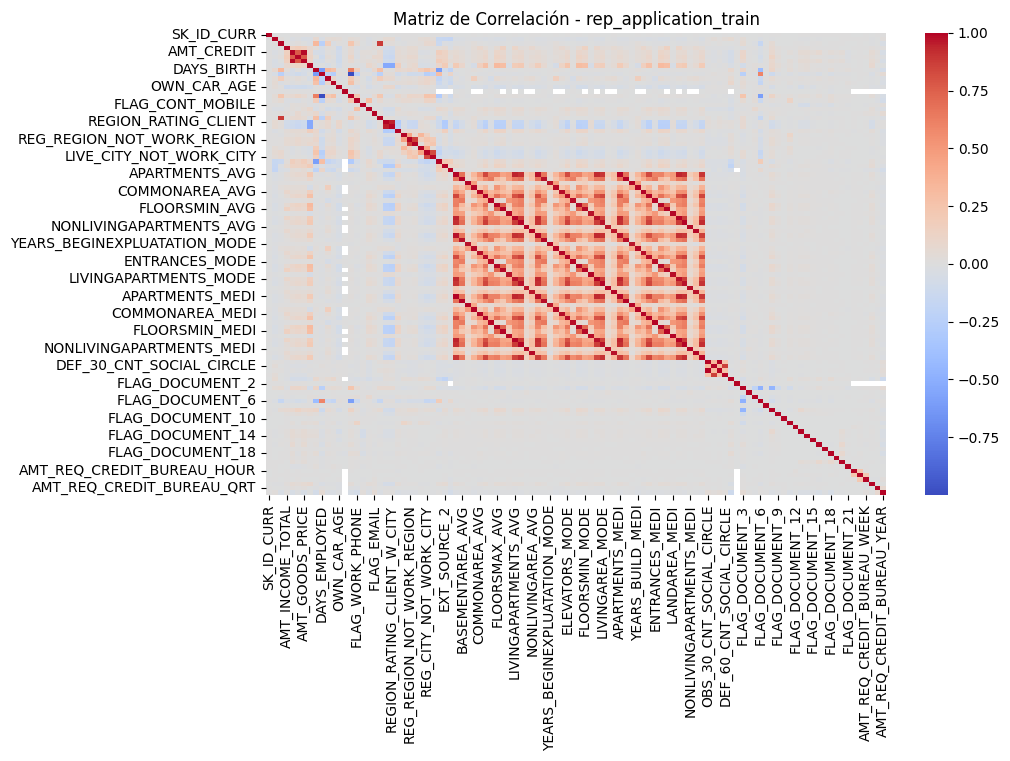

In [3]:
# Análisis de rep_application_train
table_path = DATA_DIR / 'rep_application_train.parquet'
if table_path.exists():
    table_eda = ParquetEDA(table_path)
    table_eda.run_full_analysis(target=TARGET_COL)
else:
    print("Archivo no encontrado.")

Es natural que exista una alta correlación entre las medidas de la media, moda y mediana entre sí.

--- Análisis de: rep_bureau ---
Shape: (1716428, 17)
Memoria: 433.54 MB


,Tipo,Nulos,% Nulos,Unicos
SK_ID_CURR,int32,0,0.000000,305811
SK_ID_BUREAU,int32,0,0.000000,1716428
CREDIT_ACTIVE,object,0,0.000000,4
CREDIT_CURRENCY,object,0,0.000000,4
DAYS_CREDIT,int32,0,0.000000,2923
CREDIT_DAY_OVERDUE,int32,0,0.000000,942
DAYS_CREDIT_ENDDATE,float64,105553,6.149573,14096
DAYS_ENDDATE_FACT,float64,633653,36.916958,2917
AMT_CREDIT_MAX_OVERDUE,float64,1124488,65.513264,68251
CNT_CREDIT_PROLONG,int32,0,0.000000,10



Atributos con menor varianza (posibles constantes):


,0
CNT_CREDIT_PROLONG,0.009259
CREDIT_DAY_OVERDUE,1335.495218
DAYS_ENDDATE_FACT,509811.174530
DAYS_CREDIT_UPDATE,519476.687036
DAYS_CREDIT,632287.263048


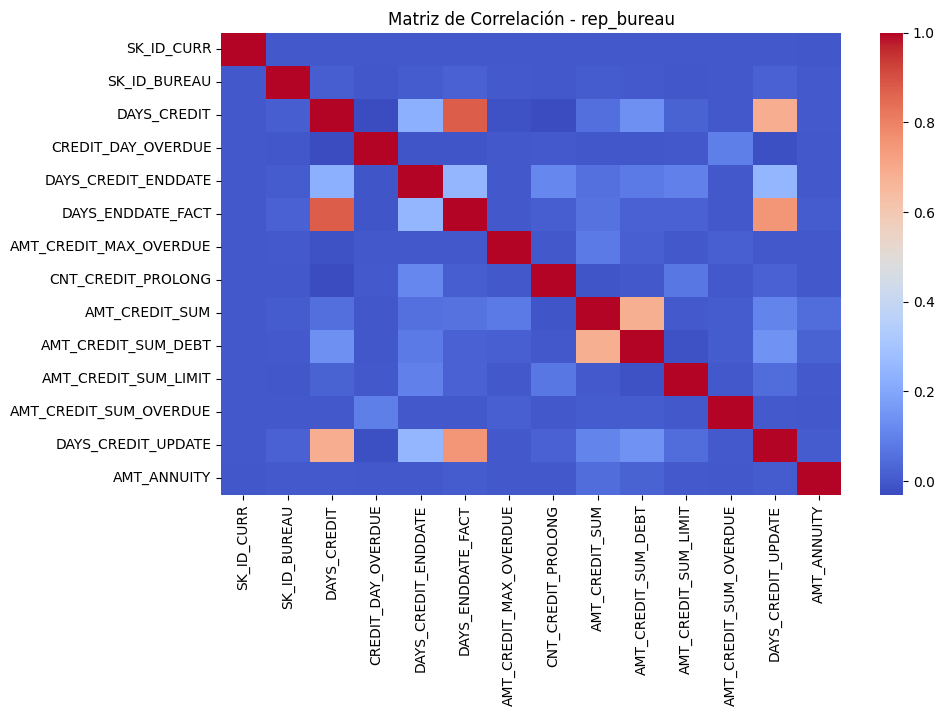

In [4]:
# Análisis de rep_bureau
table_path = DATA_DIR / 'rep_bureau.parquet'
if table_path.exists():
    table_eda = ParquetEDA(table_path)
    table_eda.run_full_analysis()
else:
    print("Archivo no encontrado.")

--- Análisis de: rep_bureau_balance ---
Shape: (27299925, 4)
Memoria: 1718.33 MB


,Tipo,Nulos,% Nulos,Unicos
_DW_ID,uint64,0,0.0,27299925
SK_ID_BUREAU,int32,0,0.0,817395
MONTHS_BALANCE,int32,0,0.0,97
STATUS,object,0,0.0,8



Atributos con menor varianza (posibles constantes):


,0
MONTHS_BALANCE,5.695148e+02
SK_ID_BUREAU,2.424074e+11
_DW_ID,6.210716e+13


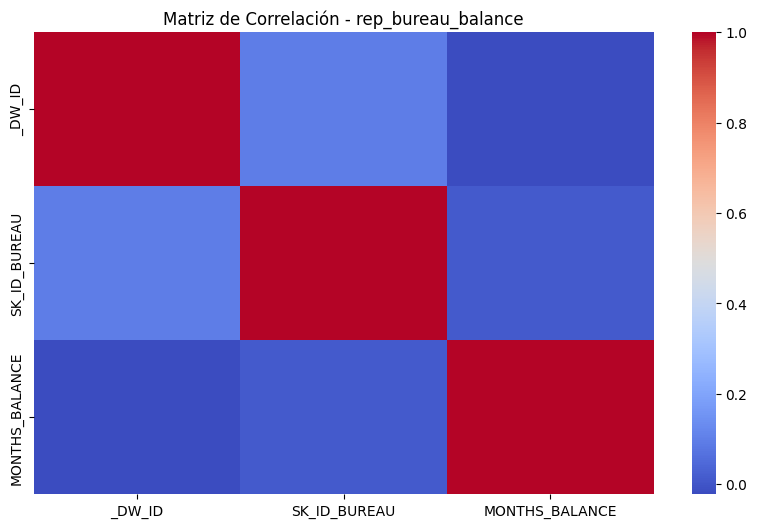

In [5]:
# Análisis de rep_bureau_balance
table_path = DATA_DIR / 'rep_bureau_balance.parquet'
if table_path.exists():
    table_eda = ParquetEDA(table_path)
    table_eda.run_full_analysis()
else:
    print("Archivo no encontrado.")

--- Análisis de: rep_credit_card_balance ---
Shape: (3840312, 24)
Memoria: 773.14 MB


,Tipo,Nulos,% Nulos,Unicos
_DW_ID,uint64,0,0.000000,3840312
SK_ID_PREV,int32,0,0.000000,104307
SK_ID_CURR,int32,0,0.000000,103558
MONTHS_BALANCE,int32,0,0.000000,96
AMT_BALANCE,float64,0,0.000000,1347904
AMT_CREDIT_LIMIT_ACTUAL,int32,0,0.000000,181
AMT_DRAWINGS_ATM_CURRENT,float64,749816,19.524872,2267
AMT_DRAWINGS_CURRENT,float64,0,0.000000,187005
AMT_DRAWINGS_OTHER_CURRENT,float64,749816,19.524872,1832
AMT_DRAWINGS_POS_CURRENT,float64,749816,19.524872,168748



Atributos con menor varianza (posibles constantes):


,0
CNT_DRAWINGS_OTHER_CURRENT,0.006829
CNT_DRAWINGS_ATM_CURRENT,1.210883
CNT_DRAWINGS_CURRENT,10.178313
CNT_DRAWINGS_POS_CURRENT,10.501807
CNT_INSTALMENT_MATURE_CUM,402.062405


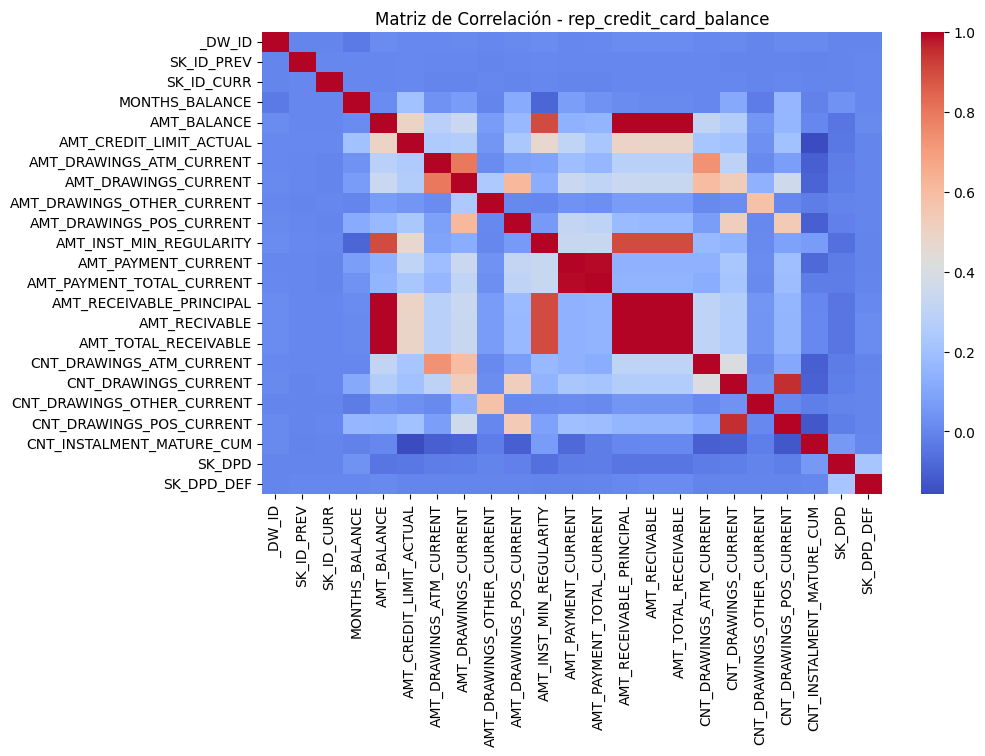

In [6]:
# Análisis de rep_credit_card_balance
table_path = DATA_DIR / 'rep_credit_card_balance.parquet'
if table_path.exists():
    table_eda = ParquetEDA(table_path)
    table_eda.run_full_analysis()
else:
    print("Archivo no encontrado.")

--- Análisis de: rep_installments_payments ---
Shape: (13605401, 9)
Memoria: 674.71 MB


,Tipo,Nulos,% Nulos,Unicos
_DW_ID,uint64,0,0.000000,13605401
SK_ID_PREV,int32,0,0.000000,997752
SK_ID_CURR,int32,0,0.000000,339587
NUM_INSTALMENT_VERSION,int32,0,0.000000,65
NUM_INSTALMENT_NUMBER,int32,0,0.000000,277
DAYS_INSTALMENT,int32,0,0.000000,2922
DAYS_ENTRY_PAYMENT,float64,2905,0.021352,3039
AMT_INSTALMENT,float64,0,0.000000,902539
AMT_PAYMENT,float64,2905,0.021352,944235



Atributos con menor varianza (posibles constantes):


,0
NUM_INSTALMENT_VERSION,1.071672e+00
NUM_INSTALMENT_NUMBER,7.109725e+02
DAYS_ENTRY_PAYMENT,6.409378e+05
DAYS_INSTALMENT,6.415150e+05
AMT_INSTALMENT,2.557351e+09


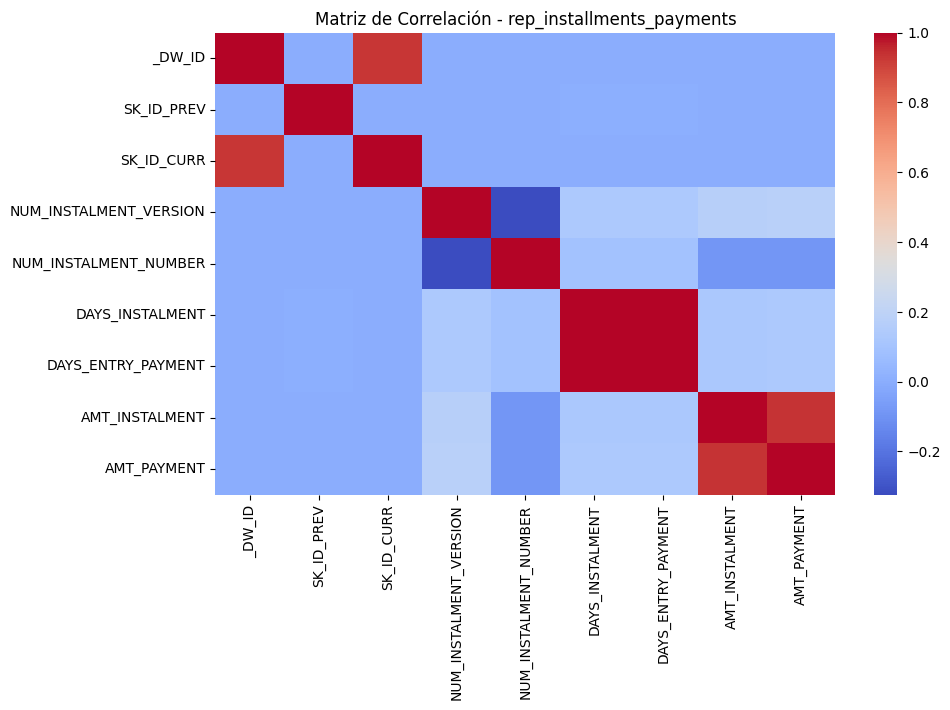

In [7]:
# Análisis de rep_installments_payments
table_path = DATA_DIR / 'rep_installments_payments.parquet'
if table_path.exists():
    table_eda = ParquetEDA(table_path)
    table_eda.run_full_analysis()
else:
    print("Archivo no encontrado.")

--- Análisis de: rep_pos_cash_balance ---
Shape: (10001358, 9)
Memoria: 946.49 MB


,Tipo,Nulos,% Nulos,Unicos
_DW_ID,uint64,0,0.000000,10001358
SK_ID_PREV,int32,0,0.000000,936325
SK_ID_CURR,int32,0,0.000000,337252
MONTHS_BALANCE,int32,0,0.000000,96
CNT_INSTALMENT,float64,26071,0.260675,73
CNT_INSTALMENT_FUTURE,float64,26087,0.260835,79
NAME_CONTRACT_STATUS,object,0,0.000000,9
SK_DPD,int32,0,0.000000,3400
SK_DPD_DEF,int32,0,0.000000,2307



Atributos con menor varianza (posibles constantes):


,0
CNT_INSTALMENT_FUTURE,123.411162
CNT_INSTALMENT,143.881368
MONTHS_BALANCE,679.466070
SK_DPD_DEF,1073.380787
SK_DPD,17613.017341


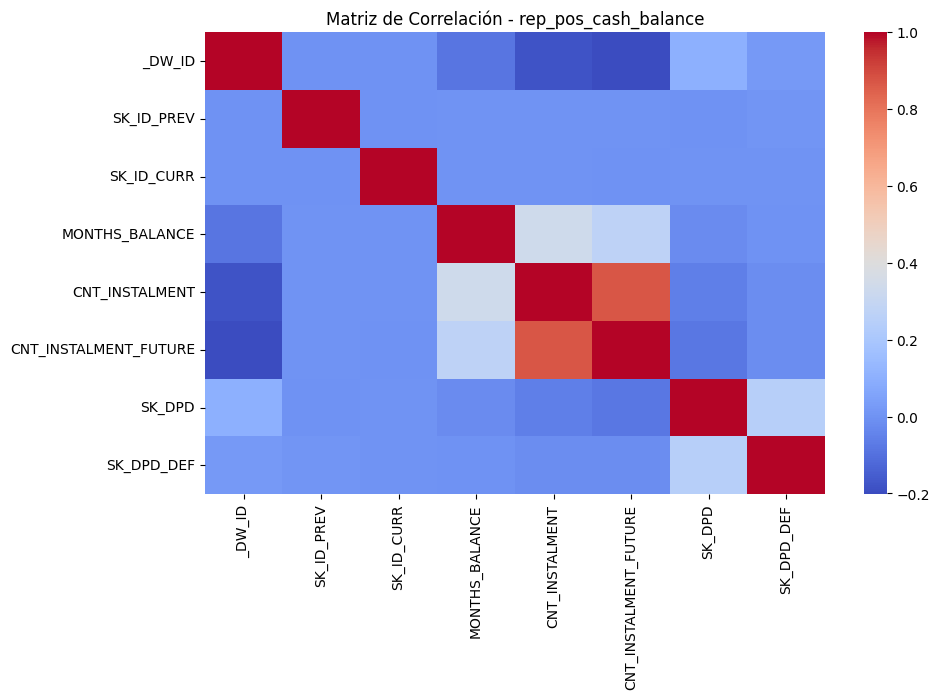

In [8]:
# Análisis de rep_pos_cash_balance
table_path = DATA_DIR / 'rep_pos_cash_balance.parquet'
if table_path.exists():
    table_eda = ParquetEDA(table_path)
    table_eda.run_full_analysis()
else:
    print("Archivo no encontrado.")

--- Análisis de: rep_previous_application ---
Shape: (1670214, 37)
Memoria: 1658.52 MB


,Tipo,Nulos,% Nulos,Unicos
SK_ID_PREV,int32,0,0.000000,1670214
SK_ID_CURR,int32,0,0.000000,338857
NAME_CONTRACT_TYPE,object,0,0.000000,4
AMT_ANNUITY,float64,372235,22.286665,357959
AMT_APPLICATION,float64,0,0.000000,93885
AMT_CREDIT,float64,1,0.000060,86803
AMT_DOWN_PAYMENT,float64,895844,53.636480,29278
AMT_GOODS_PRICE,float64,385515,23.081773,93885
WEEKDAY_APPR_PROCESS_START,object,0,0.000000,7
HOUR_APPR_PROCESS_START,int32,0,0.000000,24



Atributos con menor varianza (posibles constantes):


,0
NFLAG_LAST_APPL_IN_DAY,0.003520
RATE_INTEREST_PRIMARY,0.007686
RATE_INTEREST_PRIVILEGED,0.010176
RATE_DOWN_PAYMENT,0.011626
NFLAG_INSURED_ON_APPROVAL,0.221967


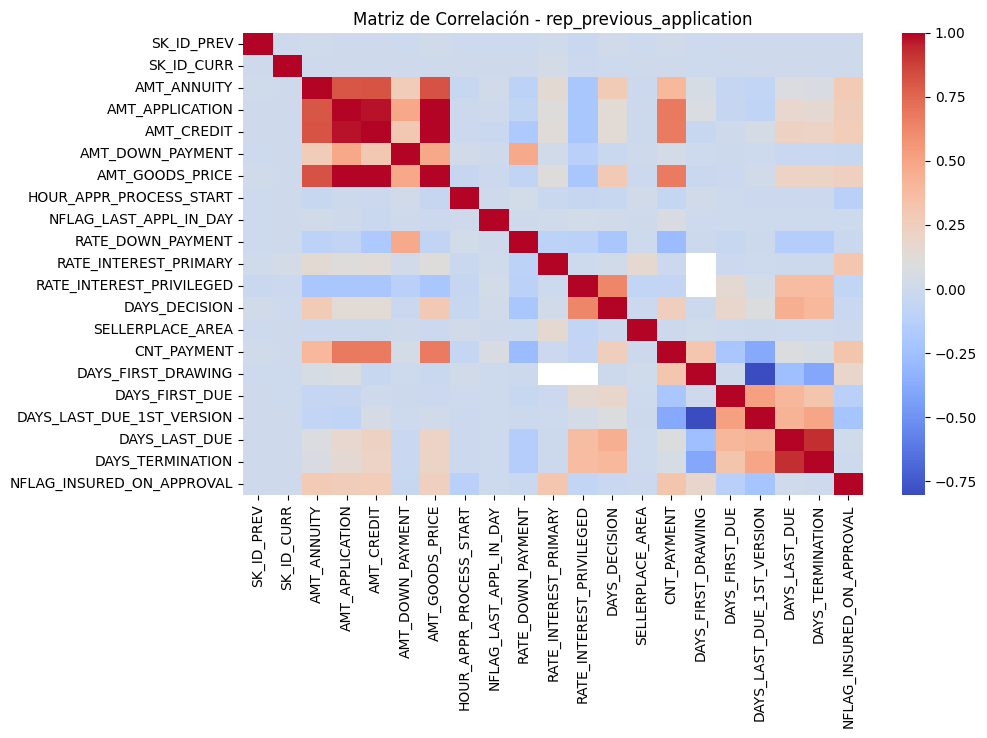

In [9]:
# Análisis de rep_previous_application
table_path = DATA_DIR / 'rep_previous_application.parquet'
if table_path.exists():
    table_eda = ParquetEDA(table_path)
    table_eda.run_full_analysis()
else:
    print("Archivo no encontrado.")

# Utilización de librería ydata-profiling

In [10]:
# Instalación de ydata-profiling
!pip install -q ydata-profiling

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 400.8/400.8 kB 2.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 296.7/296.7 kB 12.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 24.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 679.7/679.7 kB 36.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 105.4/105.4 kB 6.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.0/72.0 kB 5.7 MB/s eta 0:00:00


In [ ]:
# import pandas as pd
# from ydata_profiling import ProfileReport
# from pathlib import Path

# # Cargar la tabla principal 'rep_application_train.parquet'
# DATA_DIR = Path('./dw_parquet')
# main_table_path = DATA_DIR / 'rep_application_train.parquet'
# df_main = pd.read_parquet(main_table_path)

# print(f"Generando perfil para: {main_table_path.name}")
# # Generar el informe de perfilado
# profile = ProfileReport(df_main, title="Informe de Perfilado de Application Train")

# # Mostrar el informe (esto generará un widget interactivo o un HTML)
# profile

In [1]:
import pandas as pd
from ydata_profiling import ProfileReport
from pathlib import Path
import os, sys

# Directorio de los datos
DATA_DIR = Path('./dw_parquet')

# Directorio para guardar los informes HTML
REPORTS_DIR = Path('./profile_reports')
if not REPORTS_DIR.exists():
    REPORTS_DIR.mkdir()

print(f"Generando informes de perfilado en: {REPORTS_DIR}")

# Iterar sobre todos los archivos parquet en el directorio de datos
for file_path in DATA_DIR.glob('*.parquet'):
    file_name = file_path.name
    table_name = file_path.stem

    print(f"\n-- Procesando {file_name} --")

    if file_name in ['rep_bureau.parquet']:
      try:
          # Cargar el archivo parquet
          df = pd.read_parquet(file_path)

          # Generar el informe de perfilado
          profile = ProfileReport(df, title=f"Informe de Perfilado: {table_name}")

          # Guardar el informe como un archivo HTML
          output_html_path = REPORTS_DIR / f"{table_name}_profile_report.html"
          profile.to_file(output_html_path)

          print(f"Informe para '{file_name}' generado y guardado en {output_html_path}")
      except Exception as e:
          print(f"Error al generar el informe para {file_name}: {e}")
    else:
      pass
print("\nProceso de generación de informes completado.")

/tmp/ipykernel_5528/502875262.py:2: DeprecationWarning: 
    `import ydata_profiling` is deprecated and will not receive more updates. 
    Please install fg-data-profiling via `pip install fg-data-profiling` and use `import data_profiling` instead.
    
  from ydata_profiling import ProfileReport


Generando informes de perfilado en: profile_reports

-- Procesando rep_bureau.parquet --


Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]


100%|██████████| 17/17 [00:13<00:00,  1.21it/s]
/usr/local/lib/python3.12/dist-packages/ydata_profiling/model/pandas/discretize_pandas.py:52: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[0 0 0 ... 9 9 9]' has dtype incompatible with int32, please explicitly cast to a compatible dtype first.
  discretized_df.loc[:, column] = self._discretize_column(
/usr/local/lib/python3.12/dist-packages/ydata_profiling/model/pandas/discretize_pandas.py:52: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[0 1 1 ... 0 0 0]' has dtype incompatible with int32, please explicitly cast to a compatible dtype first.
  discretized_df.loc[:, column] = self._discretize_column(
/usr/local/lib/python3.12/dist-packages/ydata_profiling/model/pandas/discretize_pandas.py:52: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of 

Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

Export report to file:   0%|          | 0/1 [00:00<?, ?it/s]

Informe para 'rep_bureau.parquet' generado y guardado en profile_reports/rep_bureau_profile_report.html

-- Procesando rep_bureau_balance.parquet --

-- Procesando rep_pos_cash_balance.parquet --

-- Procesando rep_credit_card_balance.parquet --

-- Procesando rep_installments_payments.parquet --

-- Procesando rep_application_train.parquet --

-- Procesando rep_previous_application.parquet --

Proceso de generación de informes completado.


In [2]:
import time
import math

# Configuración
segundos_limite = 30
inicio = time.time()
encontrados = 0
numero_a_probar = 10**7  # Empezamos con un número grande

print(f"🚀 Iniciando procesamiento intenso por {segundos_limite} segundos...")

while True:
    # 1. Verificación del tiempo (Elapser)
    tiempo_transcurrido = time.time() - inicio
    if tiempo_transcurrido >= segundos_limite:
        break

    # 2. Operación "compleja": Verificación de primalidad (fuerza bruta optimizada)
    # Buscamos si el número es divisible por algún d tal que 2 <= d <= sqrt(n)
    es_primo = True
    for i in range(2, int(math.sqrt(numero_a_probar)) + 1):
        if numero_a_probar % i == 0:
            es_primo = False
            break

    if es_primo:
        encontrados += 1

    # 3. Feedback visual (opcional)
    # El end="\r" sobreescribe la misma línea para no llenar el log de Colab
    print(f"⏳ Tiempo: {tiempo_transcurrido:.1f}s | Primos hallados: {encontrados} | Probando: {numero_a_probar}", end="\r")

    numero_a_probar += 1

print(f"\n\n✅ Proceso finalizado.")
print(f"Total de números primos encontrados en el rango: {encontrados}")

🚀 Iniciando procesamiento intenso por 30 segundos...
⏳ Tiempo: 30.0s | Primos hallados: 39588 | Probando: 10638697

✅ Proceso finalizado.
Total de números primos encontrados en el rango: 39588


In [3]:
profile.to_notebook_iframe()

Output hidden; open in https://colab.research.google.com to view.

In [5]:
profile.to_file(output_file='test.html')

Export report to file:   0%|          | 0/1 [00:00<?, ?it/s]